# CommittedAgent vs CommittedAgent Lambda Sweep

This notebook analyzes `CommittedAgent` vs `CommittedAgent` simulations for `2P3G`, sweeping `lambda` from 0 to 10. Each lambda value uses 30 simulated sessions, with 12 `2P3G` trials per session.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SWEEP_DIR = Path('committed_vs_committed_lambda_sweep')
LAMBDAS = list(range(11))

In [2]:
def mean_ci(values):
    values = np.asarray([v for v in values if pd.notna(v)], dtype=float)
    if values.size == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(np.mean(values))
    sd = float(np.std(values, ddof=1)) if values.size > 1 else 0.0
    se = sd / np.sqrt(values.size) if values.size else np.nan
    ci = 1.96 * se if np.isfinite(se) else np.nan
    return mean, mean - ci, mean + ci, int(values.size)


rows = []
for lam in LAMBDAS:
    summary_path = SWEEP_DIR / f'committed_vs_committed_2p3g_summary_lambda_{lam}_sessions_0_to_29.json'
    metrics_path = SWEEP_DIR / f'committed_vs_committed_2p3g_notebook_metrics_lambda_{lam}_sessions_0_to_29.json'

    summary = json.loads(summary_path.read_text())
    metrics = json.loads(metrics_path.read_text())['summary']

    success_mean, success_low, success_high, success_n = mean_ci(
        [row['successRate'] for row in summary['sessionSummaries']]
    )
    commitment_mean, commitment_low, commitment_high, commitment_n = mean_ci(
        [row['commitmentRate'] for row in summary['sessionSummaries']]
    )
    efficiency = metrics['overall']['efficiency_success_only']
    signaling = metrics['overall']['signaling_all_new_goal']

    rows.append({
        'lambda': lam,
        'total_trials': summary['totalTrials'],
        'successful_trials': summary['successfulTrials'],
        'success_rate': summary['successRate'],
        'success_mean': success_mean,
        'success_ci_lower': success_low,
        'success_ci_upper': success_high,
        'success_n': success_n,
        'commitment_rate': summary['commitmentRate'],
        'commitment_mean': commitment_mean,
        'commitment_ci_lower': commitment_low,
        'commitment_ci_upper': commitment_high,
        'commitment_n': commitment_n,
        'efficiency_mean': efficiency['mean'] / 100.0,
        'efficiency_ci_lower': efficiency['ci_lower'] / 100.0,
        'efficiency_ci_upper': efficiency['ci_upper'] / 100.0,
        'efficiency_n': efficiency['n_participants'],
        'signaling_mean': signaling['mean'],
        'signaling_ci_lower': signaling['ci_lower'],
        'signaling_ci_upper': signaling['ci_upper'],
        'signaling_n': signaling['n_participants'],
    })

df = pd.DataFrame(rows)
df.to_csv(SWEEP_DIR / 'committed_vs_committed_lambda_sweep_summary.csv', index=False)
df

,lambda,total_trials,successful_trials,success_rate,success_mean,success_ci_lower,success_ci_upper,success_n,commitment_rate,commitment_mean,...,commitment_ci_upper,commitment_n,efficiency_mean,efficiency_ci_lower,efficiency_ci_upper,efficiency_n,signaling_mean,signaling_ci_lower,signaling_ci_upper,signaling_n
0,0,360,319,0.886111,0.886111,0.854317,0.917906,30,0.153386,0.149405,...,0.182307,30,0.954025,0.944251,0.963800,60,0.310847,0.269782,0.351911,60
1,1,360,337,0.936111,0.936111,0.913034,0.959188,30,0.507905,0.504464,...,0.545735,30,0.929309,0.918063,0.940555,60,0.290807,0.254356,0.327258,60
2,2,360,345,0.958333,0.958333,0.939555,0.977112,30,0.650391,0.647553,...,0.702060,30,0.887880,0.871960,0.903800,60,0.288360,0.248326,0.328393,60
3,3,360,343,0.952778,0.952778,0.934108,0.971447,30,0.669960,0.669544,...,0.718828,30,0.874366,0.857163,0.891569,60,0.308631,0.266770,0.350492,60
4,4,360,339,0.941667,0.941667,0.920726,0.962607,30,0.688755,0.687864,...,0.740256,30,0.863460,0.843866,0.883053,60,0.323181,0.278633,0.367729,60
5,5,360,341,0.947222,0.947222,0.923106,0.971339,30,0.702000,0.700694,...,0.753078,30,0.865441,0.845239,0.885643,60,0.324339,0.280332,0.368345,60
6,6,360,333,0.925000,0.925000,0.897479,0.952521,30,0.708835,0.706779,...,0.757194,30,0.866841,0.846126,0.887556,60,0.327943,0.282044,0.373842,60
7,7,360,335,0.930556,0.930556,0.903333,0.957778,30,0.747984,0.744907,...,0.790046,30,0.854388,0.833256,0.875520,60,0.337302,0.290544,0.384059,60
8,8,360,337,0.936111,0.936111,0.911742,0.960480,30,0.770916,0.769742,...,0.815835,30,0.850661,0.831150,0.870172,60,0.334094,0.288313,0.379875,60
9,9,360,338,0.938889,0.938889,0.912994,0.964783,30,0.786561,0.786409,...,0.830404,30,0.846220,0.827539,0.864902,60,0.346528,0.301452,0.391604,60


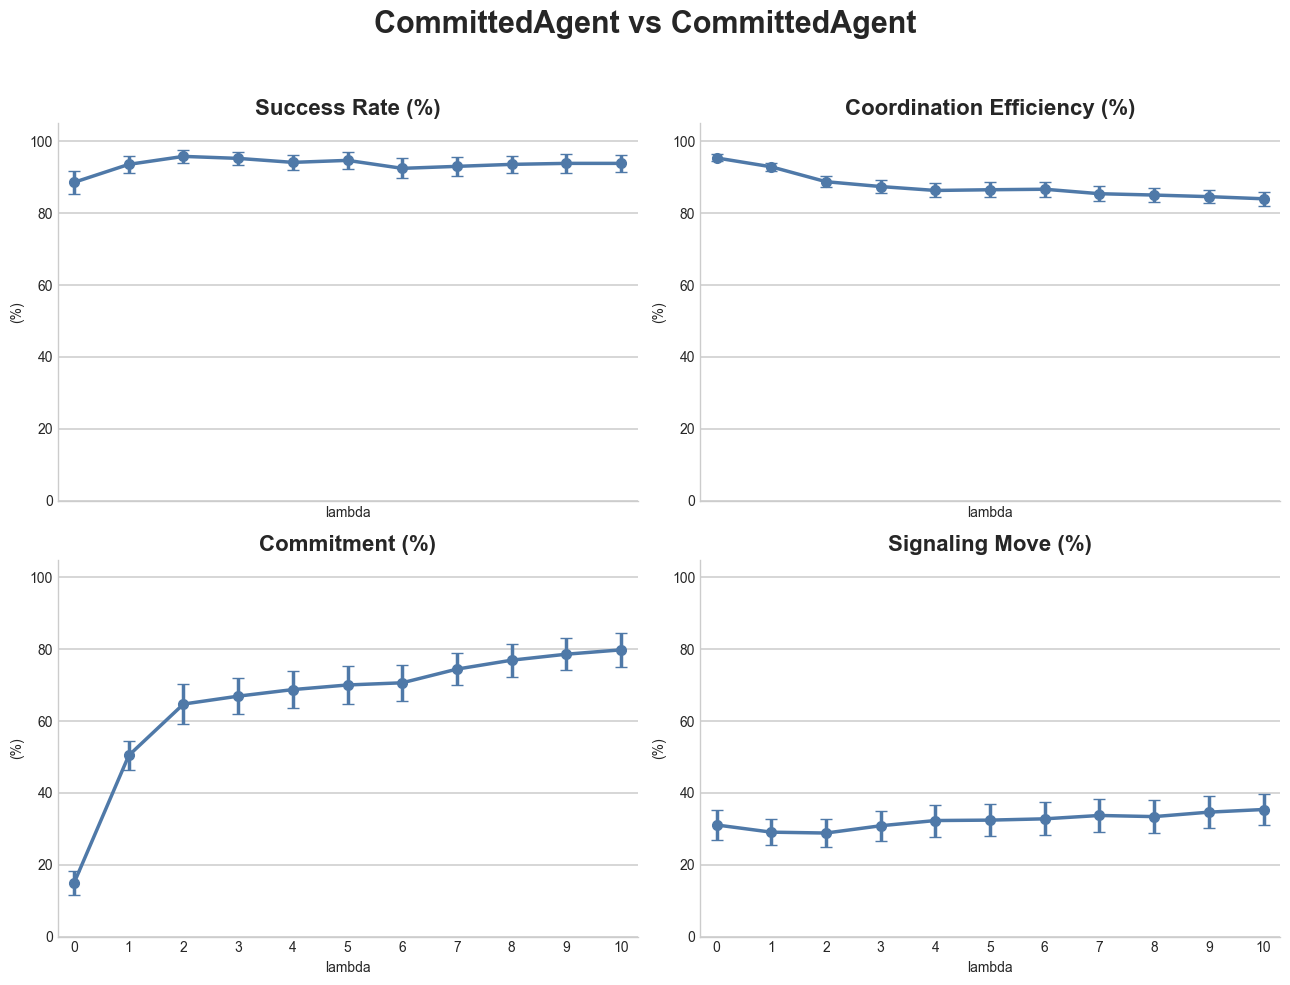

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True)
fig.suptitle('CommittedAgent vs CommittedAgent', fontsize=22, fontweight='bold', y=0.98)

panels = [
    ('Success Rate (%)', 'success_mean', 'success_ci_lower', 'success_ci_upper'),
    ('Coordination Efficiency (%)', 'efficiency_mean', 'efficiency_ci_lower', 'efficiency_ci_upper'),
    ('Commitment (%)', 'commitment_mean', 'commitment_ci_lower', 'commitment_ci_upper'),
    ('Signaling Move (%)', 'signaling_mean', 'signaling_ci_lower', 'signaling_ci_upper'),
]

color = '#4f79a8'
for ax, (title, mean_col, low_col, high_col) in zip(axes.ravel(), panels):
    x = df['lambda'].to_numpy()
    y = df[mean_col].to_numpy() * 100
    low = df[low_col].to_numpy() * 100
    high = df[high_col].to_numpy() * 100
    yerr = np.vstack([y - low, high - y])

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        color=color,
        marker='o',
        linewidth=2.5,
        markersize=7,
        capsize=4,
    )
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_xlim(-0.3, 10.3)
    ax.set_xticks(LAMBDAS)
    ax.set_xlabel('lambda')
    ax.set_ylabel('(%)')
    ax.grid(axis='y', color='#cfcfcf', linewidth=1.2)
    ax.grid(axis='x', visible=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(SWEEP_DIR / 'committed_vs_committed_lambda_sweep_4panel.png', dpi=200, bbox_inches='tight')
plt.show()

In [4]:
display_cols = [
    'lambda',
    'success_rate',
    'efficiency_mean',
    'commitment_rate',
    'signaling_mean',
]
display_df = df[display_cols].copy()
for col in display_cols[1:]:
    display_df[col] = display_df[col] * 100
display_df.round(2)

,lambda,success_rate,efficiency_mean,commitment_rate,signaling_mean
0,0,88.61,95.40,15.34,31.08
1,1,93.61,92.93,50.79,29.08
2,2,95.83,88.79,65.04,28.84
3,3,95.28,87.44,67.00,30.86
4,4,94.17,86.35,68.88,32.32
5,5,94.72,86.54,70.20,32.43
6,6,92.50,86.68,70.88,32.79
7,7,93.06,85.44,74.80,33.73
8,8,93.61,85.07,77.09,33.41
9,9,93.89,84.62,78.66,34.65
